In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.tree import plot_tree
from sklearn.compose import TransformedTargetRegressor

df_rumah= pd.read_csv('housing.csv')
df_rumah.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


DT Regression

In [82]:
df_rumah.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [83]:
y = df_rumah['price']

X = df_rumah.drop(columns=['price'])
X = pd.get_dummies(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [84]:
scaler = StandardScaler()
kolom_nomor = X_train.select_dtypes(include=['float64', 'int64']).columns
X_train[kolom_nomor] = scaler.fit_transform(X_train[kolom_nomor])
X_test[kolom_nomor] = scaler.transform(X_test[kolom_nomor])
df_rumah.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [85]:
model_tree = DecisionTreeRegressor(max_depth=6)
model_tree.fit(X_train, y_train)
prediksi_tree = model_tree.predict(X_test)
mae_tree = mean_absolute_error(y_test, prediksi_tree)
mse_tree = mean_squared_error(y_test, prediksi_tree)
r2_tree = r2_score(y_test, prediksi_tree)
print("Mean Absolute Error (Decision Tree):", mae_tree)
print("Mean Squared Error (Decision Tree):", mse_tree)
print("R² Score (Decision Tree):", r2_tree)

Mean Absolute Error (Decision Tree): 1197772.1238406869
Mean Squared Error (Decision Tree): 2517338787777.6357
R² Score (Decision Tree): 0.5019677905177783


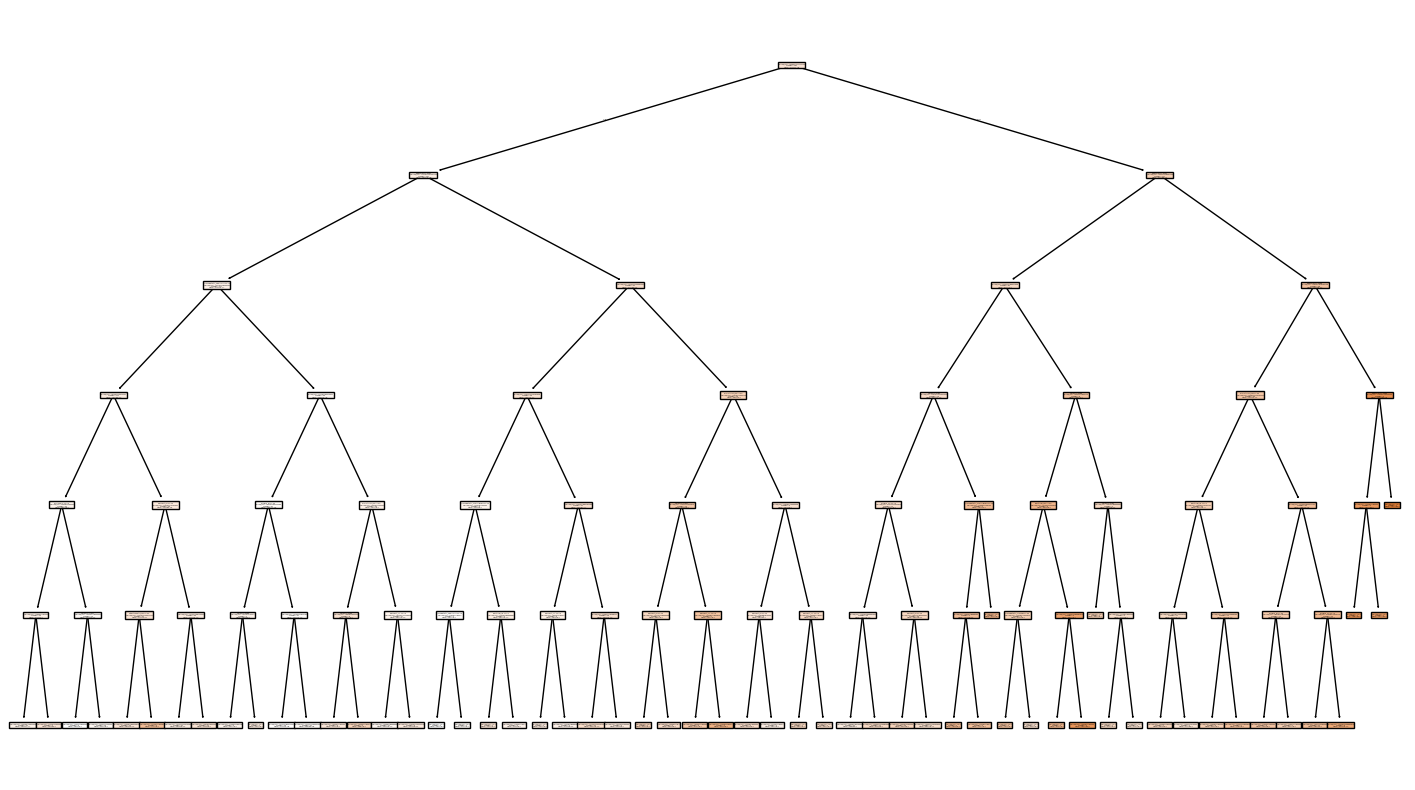

In [86]:
plt.figure(figsize=(18,10))
plot_tree(model_tree, filled=True, feature_names=X.columns)
plt.show()

SV Regression

In [87]:
model_svr = TransformedTargetRegressor(regressor=SVR(kernel='rbf'), transformer=StandardScaler())
model_svr.fit(X_train, y_train)
prediksi_svr = model_svr.predict(X_test)
mae_svr = mean_absolute_error(y_test, prediksi_svr)
mse_svr = mean_squared_error(y_test, prediksi_svr)
r2_svr = r2_score(y_test, prediksi_svr)
print("Mean Absolute Error (SVR):", mae_svr)
print("Mean Squared Error (SVR):", mse_svr)
print("R² Score (SVR):", r2_svr)

Mean Absolute Error (SVR): 1050276.0224633245
Mean Squared Error (SVR): 2080354098168.3555
R² Score (SVR): 0.5884211719746872


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


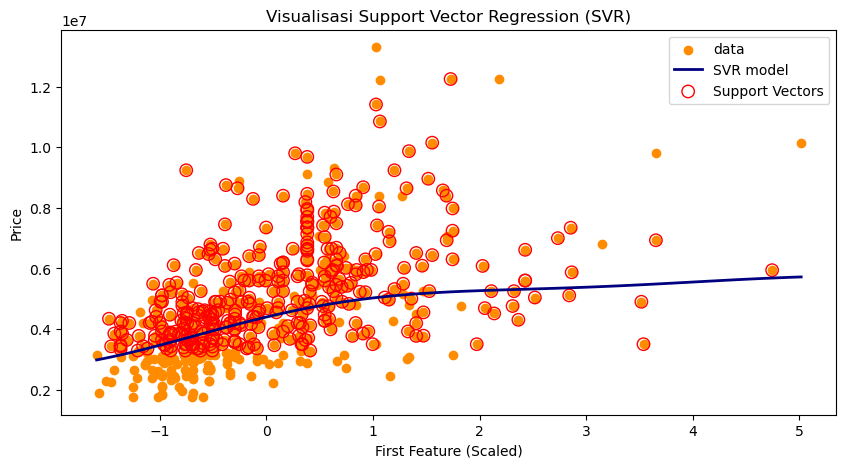

In [ ]:
plt.figure(figsize=(10, 5))


kolom_nomor = X.select_dtypes(include=['float64', 'int64']).columns
X_scaled = X.copy()
X_scaled[kolom_nomor] = scaler.transform(X[kolom_nomor])

X_single = X_scaled.iloc[:, 0].values.reshape(-1, 1)
y_values = y.values
X_plot = np.linspace(X_single.min(), X_single.max(), 100).reshape(-1, 1)
X_plot_full = np.hstack([X_plot, np.tile(X_scaled.iloc[:, 1:].mean().values, (X_plot.shape[0], 1))])

y_plot = model_svr.predict(X_plot_full)

plt.scatter(X_single, y_values, color='darkorange', label='data')
plt.plot(X_plot, y_plot, color='navy', lw=2, label='SVR model')
support_indices = model_svr.regressor_.support_
plt.scatter(X_single[support_indices], y_values[support_indices], s=80, facecolors='none', 
            edgecolors='red', label='Support Vectors')
plt.xlabel('First Feature (Scaled)')
plt.ylabel('Price')
plt.title('Visualisasi Support Vector Regression (SVR)')
plt.legend()
plt.show()